In [ ]:
#Super Market Sales Analysis 

###Objective 
To analyze supermarket sales data, identify sales patterns and customer behaviour,
visualize important business insights, and develop machine learning models
for sales prediction.

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

In [19]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\archive (8)\Sample - Superstore.csv")

In [20]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2021-103800,03-01-2021,07-01-2021,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2021-112326,04-01-2021,08-01-2021,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2021-112326,04-01-2021,08-01-2021,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2021-112326,04-01-2021,08-01-2021,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2021-141817,05-01-2021,12-01-2021,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [23]:
df.shape

(10194, 21)

In [24]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  str    
 6   Customer Name   10194 non-null  str    
 7   Segment         10194 non-null  str    
 8   Country/Region  10194 non-null  str    
 9   City            10194 non-null  str    
 10  State/Province  10194 non-null  str    
 11  Postal Code     10194 non-null  str    
 12  Region          10194 non-null  str    
 13  Product ID      10194 non-null  str    
 14  Category        10194 non-null  str    
 15  Sub-Category    10194 non-null  str    
 16  Product Name    10194 non-null  str    
 17  Sales           10194 non-null  float64
 1

In [26]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


In [29]:
df.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.dtypes

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object

In [33]:
df['Order Date'].head(10)

0    03-01-2021
1    04-01-2021
2    04-01-2021
3    04-01-2021
4    05-01-2021
5    06-01-2021
6    06-01-2021
7    06-01-2021
8    06-01-2021
9    06-01-2021
Name: Order Date, dtype: str

In [34]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d-%m-%Y'
)

In [35]:
df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='%d-%m-%Y'
)

In [36]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2021-01-03,2021-01-07
1,2021-01-04,2021-01-08
2,2021-01-04,2021-01-08
3,2021-01-04,2021-01-08
4,2021-01-05,2021-01-12


In [37]:
df['Year'] = df['Order Date'].dt.year

In [38]:
df['Month'] = df['Order Date'].dt.month

In [39]:
df['Month_Name'] = df['Order Date'].dt.month_name()

In [40]:
df['Day_Name'] = df['Order Date'].dt.day_name()

In [41]:
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [42]:
df[['Order Date',
    'Ship Date',
    'Year',
    'Month',
    'Month_Name',
    'Day_Name',
    'Shipping_Days']].head()

,Order Date,Ship Date,Year,Month,Month_Name,Day_Name,Shipping_Days
0,2021-01-03,2021-01-07,2021,1,January,Sunday,4
1,2021-01-04,2021-01-08,2021,1,January,Monday,4
2,2021-01-04,2021-01-08,2021,1,January,Monday,4
3,2021-01-04,2021-01-08,2021,1,January,Monday,4
4,2021-01-05,2021-01-12,2021,1,January,Tuesday,7


In [43]:
total_sales = df['Sales'].sum()

print("Total Sales =", round(total_sales,2))


Total Sales = 2326534.35


In [44]:
total_profit = df['Profit'].sum()

print("Total Profit =", round(total_profit,2))

Total Profit = 292296.81


In [45]:
total_quantity = df['Quantity'].sum()

print("Total Quantity Sold =", total_quantity)

Total Quantity Sold = 38654


In [46]:
average_sales = df['Sales'].mean()

print("Average Sales =", round(average_sales,2))

Average Sales = 228.23


In [47]:
average_profit = df['Profit'].mean()

print("Average Profit =", round(average_profit,2))

Average Profit = 28.67


In [48]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

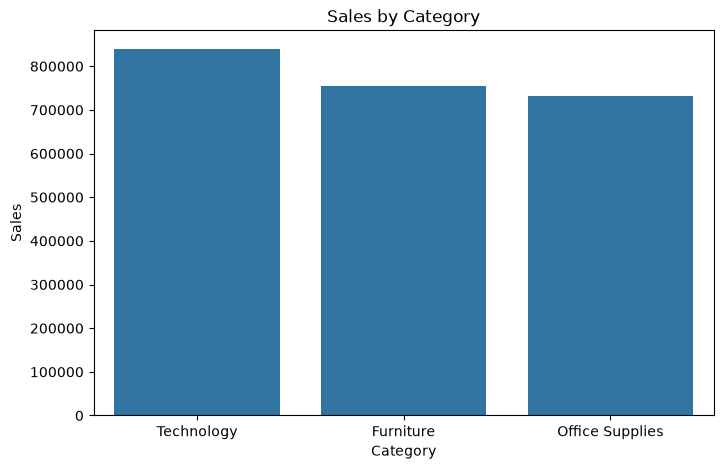

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [50]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

category_profit

Category
Technology         146543.3756
Office Supplies    126023.4434
Furniture           19729.9956
Name: Profit, dtype: float64

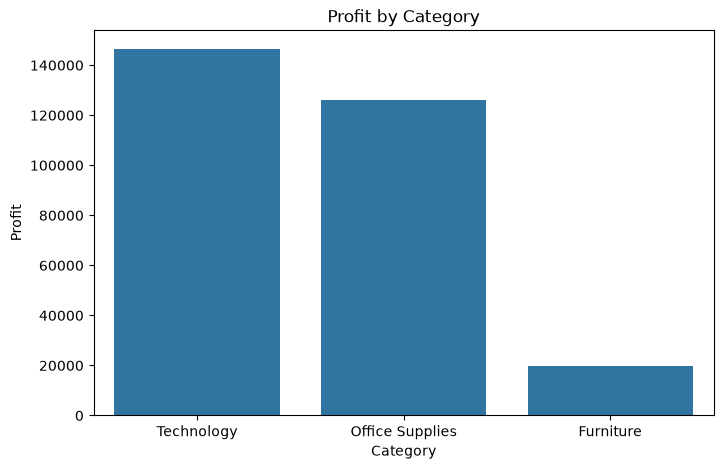

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

In [52]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales

Region
West       739813.6085
East       691828.1680
Central    503170.6728
South      391721.9050
Name: Sales, dtype: float64

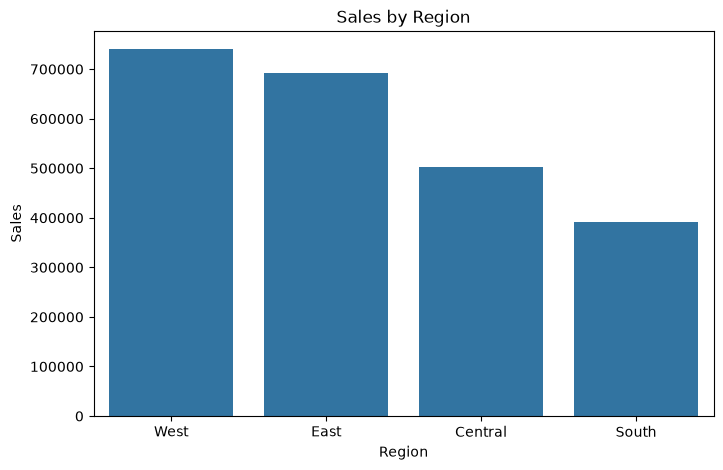

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [54]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

subcategory_sales

Sub-Category
Chairs         335768.2490
Phones         331842.6400
Storage        224644.5540
Tables         208020.1820
Binders        207354.8810
Machines       189925.0310
Accessories    167380.3180
Copiers        150745.2900
Bookcases      115361.2043
Appliances     108213.1850
Furnishings     95598.1260
Paper           79540.5380
Supplies        46725.4980
Art             27659.0140
Envelopes       16528.3620
Labels          12695.0420
Fasteners        8532.2400
Name: Sales, dtype: float64

In [54]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

subcategory_sales

Sub-Category
Chairs         335768.2490
Phones         331842.6400
Storage        224644.5540
Tables         208020.1820
Binders        207354.8810
Machines       189925.0310
Accessories    167380.3180
Copiers        150745.2900
Bookcases      115361.2043
Appliances     108213.1850
Furnishings     95598.1260
Paper           79540.5380
Supplies        46725.4980
Art             27659.0140
Envelopes       16528.3620
Labels          12695.0420
Fasteners        8532.2400
Name: Sales, dtype: float64

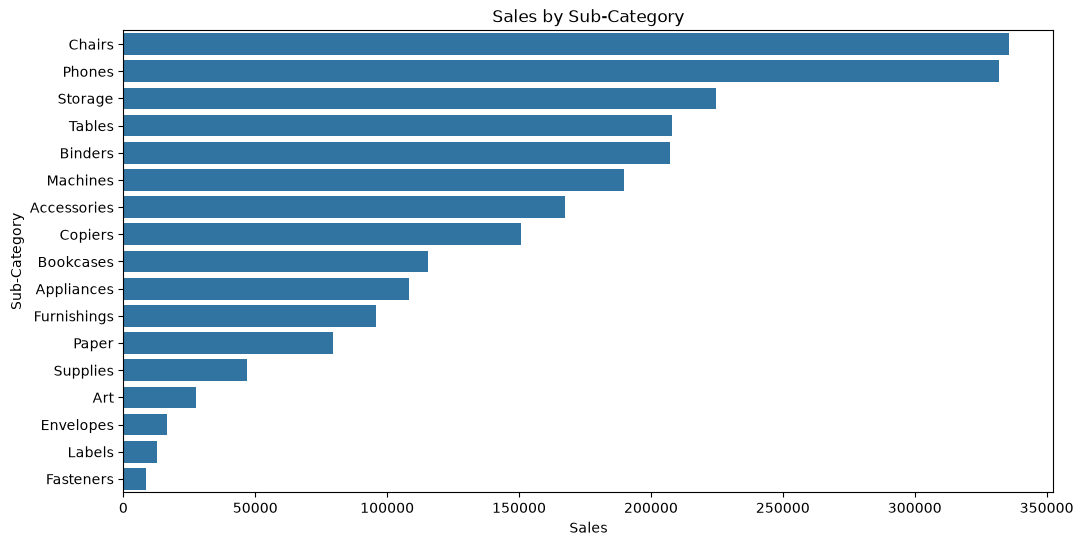

In [55]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=subcategory_sales.values,
    y=subcategory_sales.index
)

plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")

plt.show()

In [56]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

subcategory_profit

Sub-Category
Copiers        56093.9365
Phones         45050.8265
Accessories    41936.6357
Paper          34511.5070
Binders        31426.1003
Chairs         27223.5323
Storage        21285.1115
Appliances     18329.4844
Furnishings    13891.7430
Envelopes       6988.0247
Art             6653.1962
Labels          5572.7780
Machines        3461.9769
Fasteners       2428.6358
Supplies       -1171.3945
Bookcases      -3632.0736
Tables        -17753.2061
Name: Profit, dtype: float64

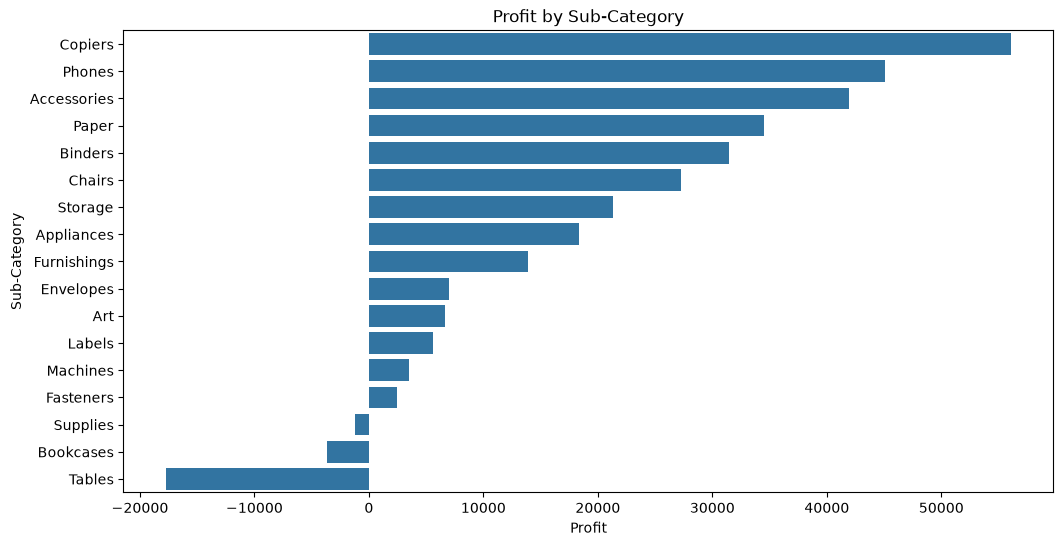

In [57]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=subcategory_profit.values,
    y=subcategory_profit.index
)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")

plt.show()

In [58]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

segment_sales

Segment
Consumer       1.170660e+06
Corporate      7.158061e+05
Home Office    4.400684e+05
Name: Sales, dtype: float64

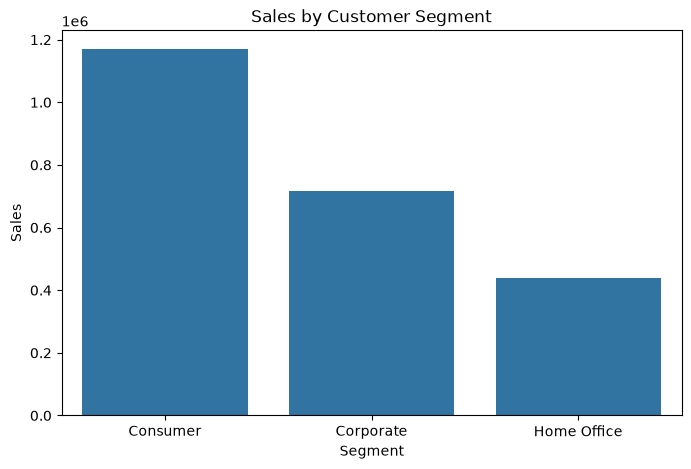

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.show()

In [60]:
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

segment_profit

Segment
Consumer       136371.4463
Corporate       94249.6400
Home Office     61675.7283
Name: Profit, dtype: float64

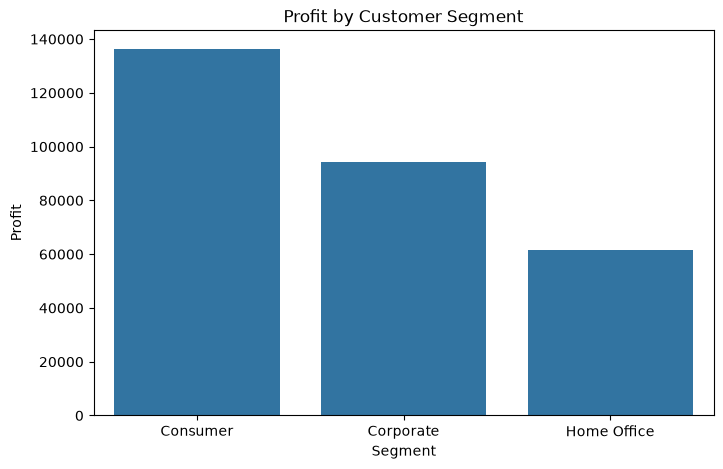

In [61]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_profit.index,
    y=segment_profit.values
)

plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")

plt.show()

In [62]:
monthly_sales = df.groupby('Month_Name')['Sales'].sum()

monthly_sales

Month_Name
April        138098.7486
August       161821.9150
December     330218.1755
February      59751.2514
January       96069.5156
July         149001.7130
June         153459.9973
March        210672.0868
May          158765.0337
November     352665.9910
October      207126.2567
September    308883.6697
Name: Sales, dtype: float64

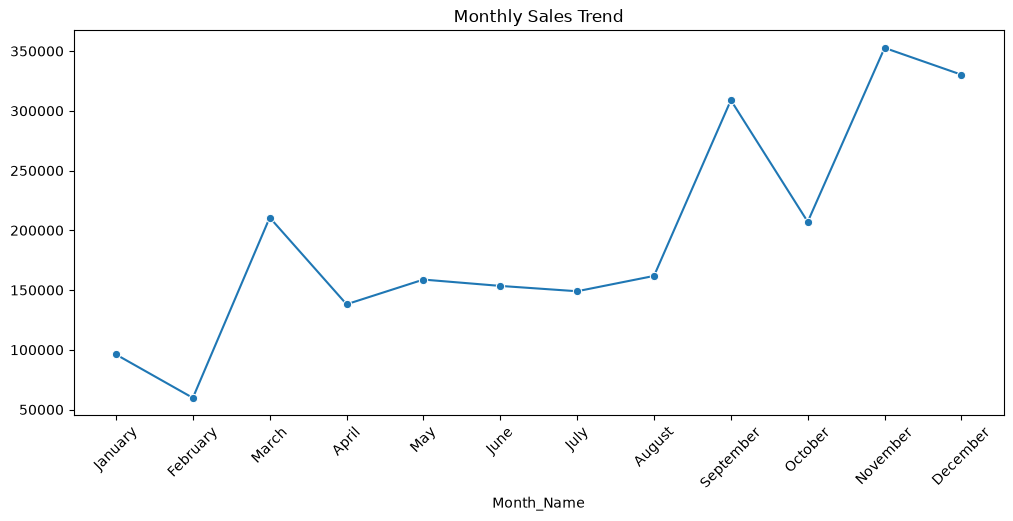

In [63]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")

plt.show()

In [64]:
yearly_sales = df.groupby('Year')['Sales'].sum()

yearly_sales

Year
2021    494040.2121
2022    472993.0310
2023    613933.5800
2024    745567.5312
Name: Sales, dtype: float64

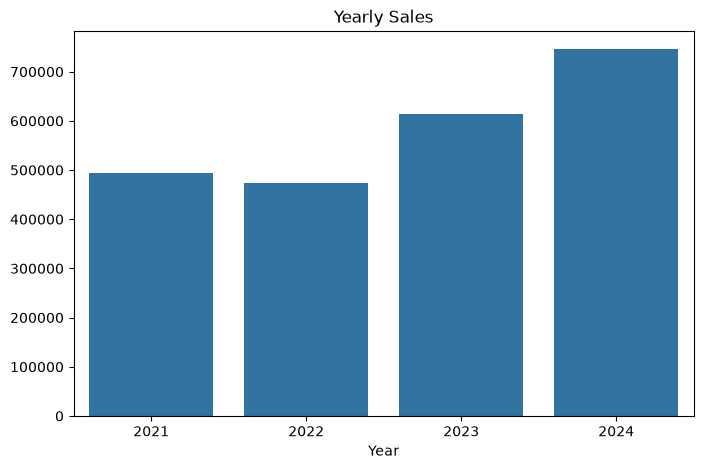

In [65]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=yearly_sales.index.astype(str),
    y=yearly_sales.values
)

plt.title("Yearly Sales")

plt.show()

In [66]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

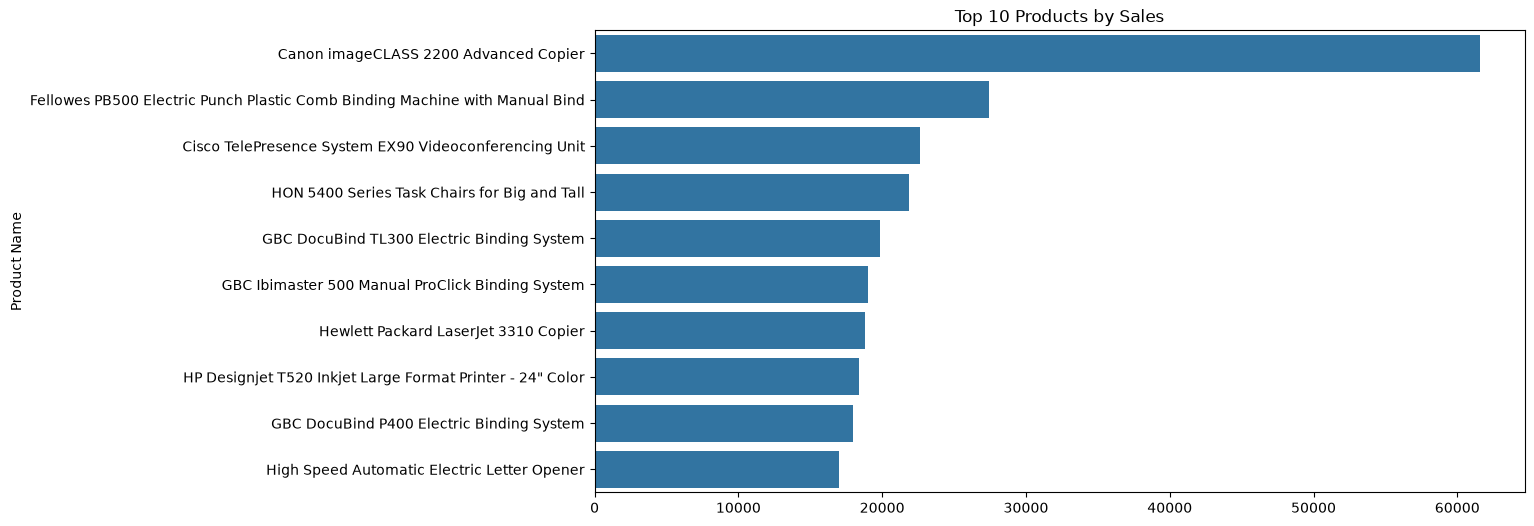

In [67]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")

plt.show()

In [68]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

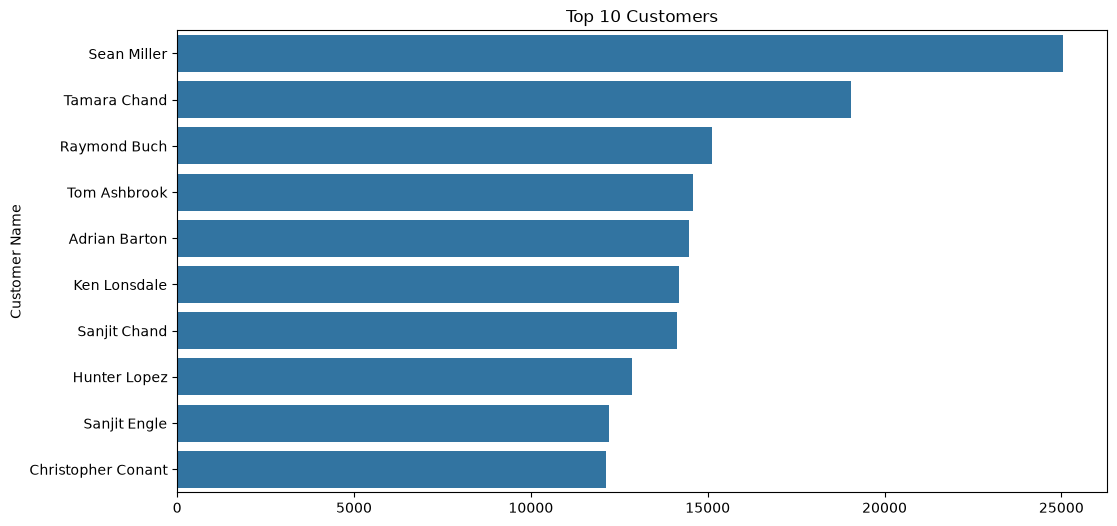

In [69]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title("Top 10 Customers")

plt.show()

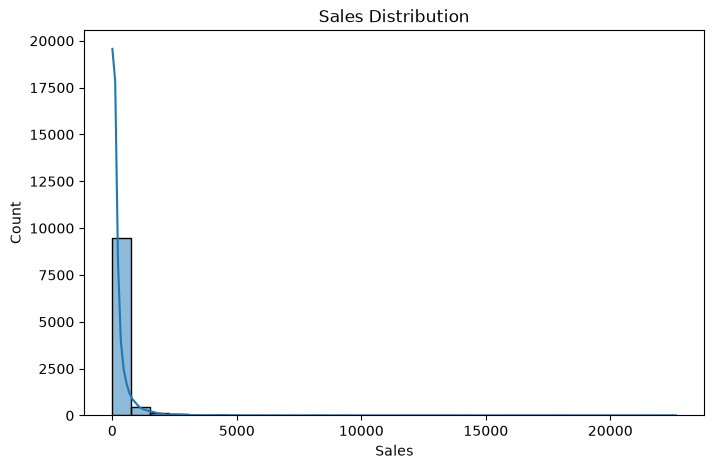

In [70]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Sales'],
    bins=30,
    kde=True
)

plt.title("Sales Distribution")

plt.show()

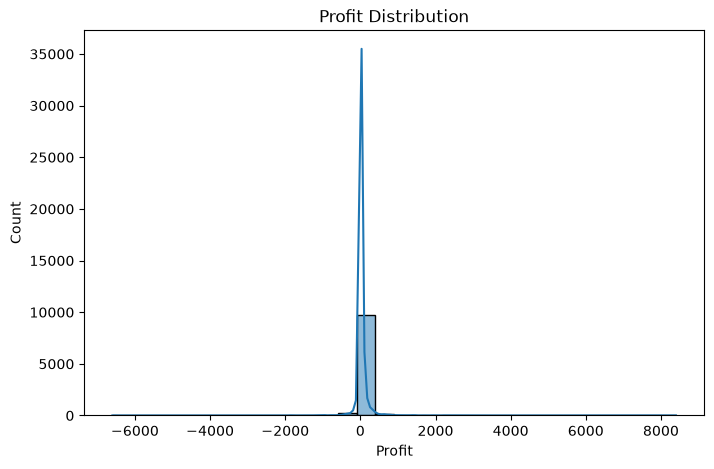

In [71]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Profit'],
    bins=30,
    kde=True
)

plt.title("Profit Distribution")

plt.show()

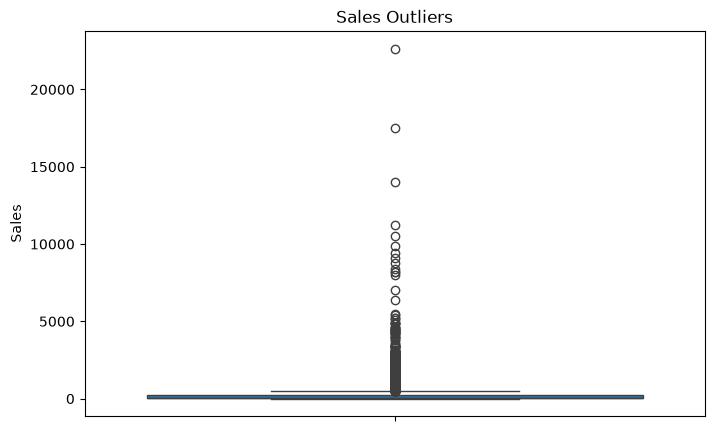

In [72]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df['Sales']
)

plt.title("Sales Outliers")

plt.show()

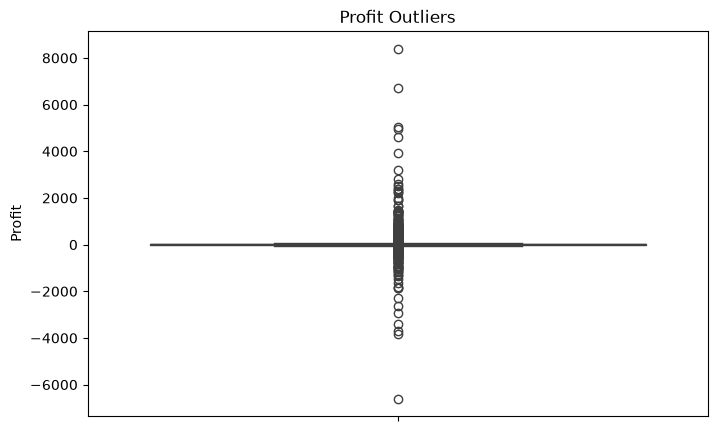

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df['Profit']
)

plt.title("Profit Outliers")

plt.show()

In [74]:
numeric_df = df.select_dtypes(include=['int64','float64'])

correlation = numeric_df.corr()

correlation

,Row ID,Sales,Quantity,Discount,Profit,Shipping_Days
Row ID,1.000000,-0.008958,0.000502,-0.001474,0.003022,-0.019600
Sales,-0.008958,1.000000,0.198457,-0.027756,0.481460,-0.007056
Quantity,0.000502,0.198457,1.000000,0.007475,0.066145,0.020852
Discount,-0.001474,-0.027756,0.007475,1.000000,-0.218882,-0.001739
Profit,0.003022,0.481460,0.066145,-0.218882,1.000000,-0.004358
Shipping_Days,-0.019600,-0.007056,0.020852,-0.001739,-0.004358,1.000000


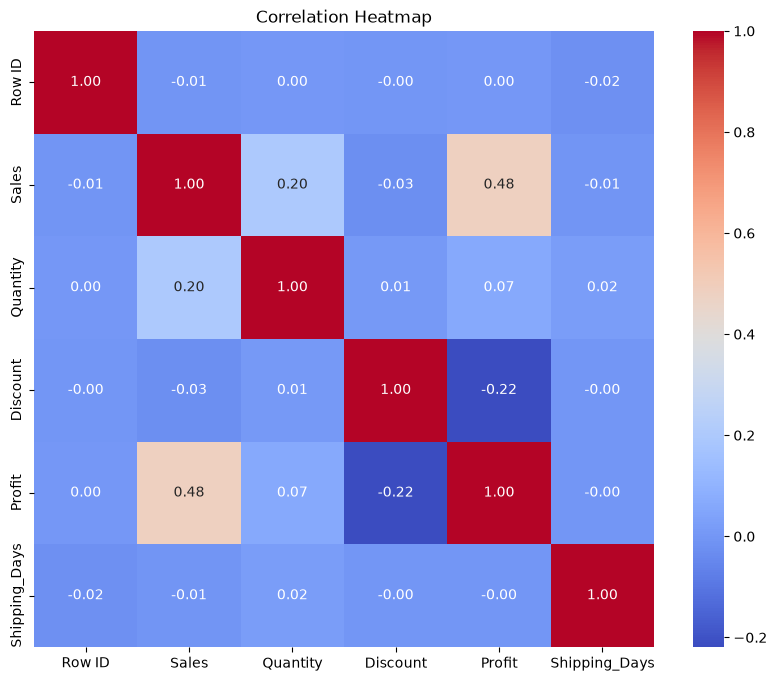

In [75]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [76]:
ml_df = df.copy()

In [77]:
ml_df = ml_df.drop([
    'Row ID',
    'Order ID',
    'Customer ID',
    'Customer Name',
    'Product ID',
    'Product Name',
    'Country/Region',
    'Postal Code',
    'Order Date',
    'Ship Date',
    'Month_Name',
    'Day_Name'
], axis=1)

In [78]:
ml_df.columns

Index(['Ship Mode', 'Segment', 'City', 'State/Province', 'Region', 'Category',
       'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month', 'Shipping_Days'],
      dtype='str')

In [79]:
ml_df.select_dtypes(include='object').columns

Index(['Ship Mode', 'Segment', 'City', 'State/Province', 'Region', 'Category',
       'Sub-Category'],
      dtype='str')

In [80]:
encoder = LabelEncoder()

for column in ml_df.select_dtypes(include='object').columns:
    ml_df[column] = encoder.fit_transform(ml_df[column])

In [81]:
ml_df.head()

,Ship Mode,Segment,City,State/Province,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month,Shipping_Days
0,3,0,211,51,0,1,12,16.448,2,0.2,5.5512,2021,1,4
1,3,2,327,13,0,1,3,3.540,2,0.8,-5.4870,2021,1,4
2,3,2,327,13,0,1,10,11.784,3,0.2,4.2717,2021,1,4
3,3,2,327,13,0,1,14,272.736,3,0.2,-64.7748,2021,1,4
4,3,0,380,43,1,1,2,19.536,3,0.2,4.8840,2021,1,7


In [82]:
X = ml_df.drop('Sales', axis=1)

In [83]:
y = ml_df['Sales']

In [84]:
X.shape

(10194, 13)

In [85]:
y.shape

(10194,)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [87]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (8155, 13)
Testing Data : (2039, 13)


In [88]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 6.78, 8.93,-0.02,...,-8.38,-0.07,-7.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['Ship Mode','Segment','City',...,'Year','Month','Shipping_Days']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.685e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [89]:
linear_prediction = linear_model.predict(X_test)

In [90]:
linear_mae = mean_absolute_error(y_test, linear_prediction)
linear_mse = mean_squared_error(y_test, linear_prediction)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_prediction)

print("Linear Regression")
print("---------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R² :", linear_r2)

Linear Regression
---------------------
MAE : 234.3168946309079
RMSE: 503.3013048442265
R² : 0.5147546627010773


In [91]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [92]:
dt_prediction = dt_model.predict(X_test)

In [93]:
dt_mae = mean_absolute_error(y_test, dt_prediction)
dt_mse = mean_squared_error(y_test, dt_prediction)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_prediction)

print("Decision Tree Regression")
print("----------------------------")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Regression
----------------------------
MAE : 107.64648827856792
RMSE: 576.2001234861596
R² Score: 0.3640075613528315


In [94]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [95]:
rf_prediction = rf_model.predict(X_test)

In [96]:
rf_mae = mean_absolute_error(y_test, rf_prediction)
rf_mse = mean_squared_error(y_test, rf_prediction)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_prediction)

print("Random Forest Regression")
print("----------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Regression
----------------------------
MAE : 77.88656632564984
RMSE: 336.50211308492976
R² Score: 0.7830893629803093


In [97]:
model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        linear_mae,
        dt_mae,
        rf_mae
    ],
    'RMSE': [
        linear_rmse,
        dt_rmse,
        rf_rmse
    ],
    'R2 Score': [
        linear_r2,
        dt_r2,
        rf_r2
    ]
})

model_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,234.316895,503.301305,0.514755
1,Decision Tree,107.646488,576.200123,0.364008
2,Random Forest,77.886566,336.502113,0.783089


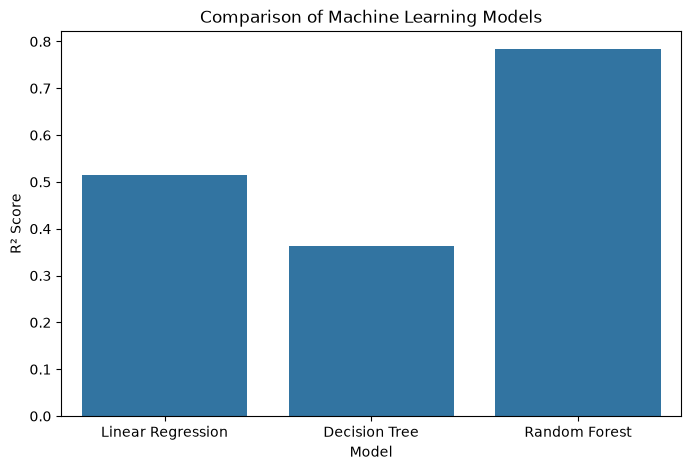

In [98]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=model_results,
    x='Model',
    y='R2 Score'
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

In [99]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
9,Profit,0.746993
11,Month,0.065725
8,Discount,0.044031
6,Sub-Category,0.034264
3,State/Province,0.023137
7,Quantity,0.018538
5,Category,0.018198
2,City,0.013573
1,Segment,0.009813
12,Shipping_Days,0.008812


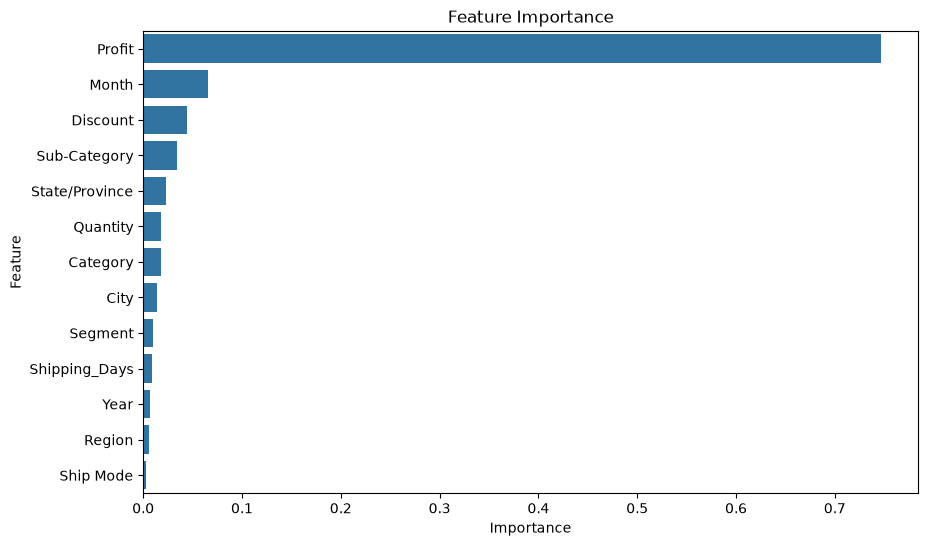

In [100]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

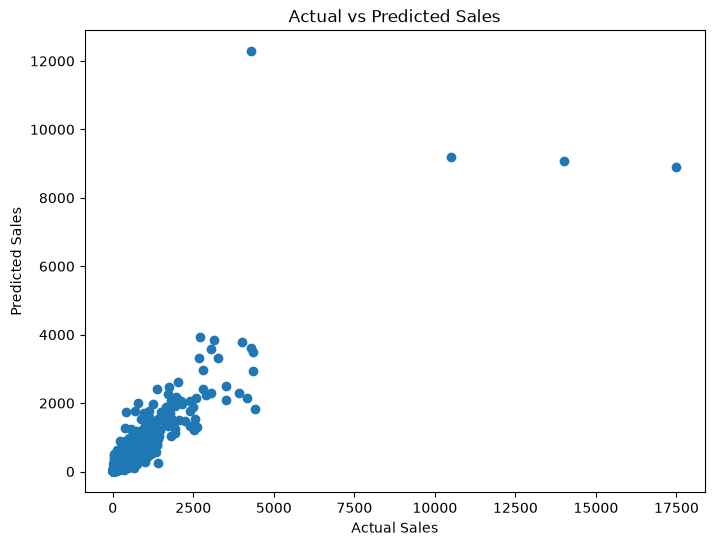

In [101]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_prediction)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [102]:
prediction_results = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': rf_prediction
})

prediction_results.head(10)

,Actual Sales,Predicted Sales
0,18.693,18.653550
1,18.176,47.950900
2,539.658,225.396722
3,772.680,564.807300
4,839.430,598.896800
5,1951.840,2175.908690
6,181.350,179.012500
7,68.940,76.832600
8,4.360,4.072720
9,58.340,61.009500


In [103]:
best_model = model_results.loc[
    model_results['R2 Score'].idxmax(),
    'Model'
]

print("Best Performing Model:", best_model)

Best Performing Model: Random Forest


In [104]:
print("=" * 50)
print("SUPERSTORE SALES ANALYSIS SUMMARY")
print("=" * 50)

print("Total Sales :", round(total_sales,2))
print("Total Profit :", round(total_profit,2))
print("Total Quantity :", total_quantity)

print("\nBest Model :", best_model)

print("\nModel Performance")
print(model_results)

SUPERSTORE SALES ANALYSIS SUMMARY
Total Sales : 2326534.35
Total Profit : 292296.81
Total Quantity : 38654

Best Model : Random Forest

Model Performance
               Model         MAE        RMSE  R2 Score
0  Linear Regression  234.316895  503.301305  0.514755
1      Decision Tree  107.646488  576.200123  0.364008
2      Random Forest   77.886566  336.502113  0.783089
